# LABORATORIO 3

* Maria Paula Ospina
* Jhon Gerardo Vega

Importación de librerias

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np


## Funciones

* Función que ayuda a identificar los outliers dada una columna y un df

In [4]:
def outliers(col, dataframe):
    data = dataframe.copy()
    mean = data[col].mean()
    std = data[col].std()

    min_range = mean - 3*std
    max_range = mean + 3*std

    return data[(data[col] < min_range) | (data[col] > max_range)]

* Función que ayuda a cambiar la categotria de una lista de columnas dentro de un df

In [5]:
def change_category(list_categories, df):
  data = df.copy()
  for col in list_categories:
    if col in data.columns:
        data[col] = data[col].astype('category')
  return data


* Función que ayuda a remover una lista de columnas dentro de un df

In [6]:
def remove_cols(list_cols_remove, df):
  data = df.copy()
  data.drop(columns=list_cols_remove, inplace=True)
  return data

## Lectura de Archivo

In [7]:
#Datos de entrenamiento
df1 = pd.read_csv('./Datos_Laboratorio3.csv', sep=';', encoding='latin-1')
pipe = df1.copy()
#Datos de prueba
df_test = pd.read_csv('./Datos_test_Lab3.csv', sep=';', encoding='latin-1')

In [8]:
df1.head()

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


In [9]:
df_test.head()

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,32,Femenino,77.3,1.54,32.59,Ganancia muscular,Lesion,Bajo,Intermedio,Vegetariano,...,0,0.0,0,0.0,0.21,169.0,8468,2.57,NaN,NaN
1,29,Masculino,79.6,1.82,24.03,General,Ninguno,Alto,Avanzado,Vegetariano,...,0,0.0,0,0.0,0.58,52.4,11967,3.73,NaN,NaN
2,33,Femenino,107.2,1.57,43.49,General,Hipertension,Alto,Principiante,Vegano,...,0,0.0,0,0.0,0.37,189.5,15950,3.06,NaN,NaN
3,42,Femenino,103.5,1.67,37.11,General,Asma,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.57,185.7,9384,2.18,NaN,NaN
4,29,Masculino,76.0,2.02,18.63,Ganancia muscular,Ninguno,Bajo,Intermedio,Pescetariano,...,0,0.0,1,23.7,0.21,182.1,10070,3.32,NaN,NaN


* Cambiar la categoria de las columnas categoricas que python ha tomado como númericas

In [10]:
category_cols = ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol','Nivel_Actividad','Nivel_experiencia','Condicion_salud','Dieta_preferida','Entrenamiento_preferido','Objetivo','Gnereo']
df1 = change_category(category_cols, df1)

df1.describe(include='all')

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
count,9698.000000,9698,9687.000000,9698.000000,9698.000000,9698,9698,9698,9698,9698,...,9698.0,9698.000000,9698.0,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698,9698
unique,NaN,3,NaN,NaN,NaN,5,7,3,3,5,...,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,4,4
top,NaN,Femenino,NaN,NaN,NaN,Ganancia muscular,Ninguno,Moderado,Intermedio,No-Vegetariano,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,Ninguno,Balanceado
freq,NaN,4719,NaN,NaN,NaN,2757,6030,3594,4100,2456,...,7493.0,NaN,6931.0,NaN,NaN,NaN,NaN,NaN,3807,4297
mean,45.112601,NaN,92.622515,1.775047,30.131391,NaN,NaN,NaN,NaN,NaN,...,NaN,2.172252,NaN,3.778841,0.500115,129.997360,9765.936482,2.748532,NaN,NaN
std,17.641045,NaN,27.383913,0.158754,10.605675,NaN,NaN,NaN,NaN,NaN,...,NaN,4.624756,NaN,7.023263,0.289062,51.981874,4762.152079,1.015342,NaN,NaN
min,15.000000,NaN,45.000000,1.500000,10.930000,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,0.000000,0.000000,40.000000,200.000000,1.000000,NaN,NaN
25%,30.000000,NaN,68.800000,1.640000,21.620000,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,0.000000,0.250000,85.000000,5608.250000,1.860000,NaN,NaN
50%,45.000000,NaN,92.600000,1.780000,29.190000,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,0.000000,0.500000,129.950000,9718.000000,2.760000,NaN,NaN
75%,61.000000,NaN,116.500000,1.910000,37.060000,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,4.300000,0.750000,175.200000,13953.000000,3.620000,NaN,NaN


Obtener todos los tipos de columnas del dataframe

In [11]:
df1.dtypes

Edad                          int64
Gnereo                     category
Peso                        float64
Altura                      float64
BMI                         float64
Objetivo                   category
Condicion_salud            category
Nivel_Actividad            category
Nivel_experiencia          category
Dieta_preferida            category
Horas_sueño                 float64
Entrenamiento_preferido    category
Cantidad_equipo               int64
Tiempo_disponible             int64
Tiene_alergia              category
Problemas_digestivos       category
Fumador                    category
Cigarrillos_dia             float64
Alcohol                    category
Alcohol_semana              float64
Score_micronutrientes       float64
Ingesta_proteinas           float64
Pasos_dia                     int64
Ingesta_agua                float64
Plan_entrenamiento              str
Plan_nutrición                  str
dtype: object

## Análisis de Variables

### Genero

De la variable genero se ha identificado un desbalanceo sobre la categoria 'Otro'

In [12]:
df1['Gnereo'].value_counts()

Gnereo
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64

### BMI

Se realizó el calculo del BMI por medio de las variables 'Peso' y 'Altura'. Posteriormente, el resultado se comparó con la columna 'BMI' y se ha descubierto, que en efecto, la columna 'BMI' es exactamente el resultado de calcular el BMI con las columnas 'Peso' y 'Altura'. Por lo tanto, se puede remover del conjuntos de datos las variables Peso y Altura, pues su información ya está contenida dentro de la variable 'BMI'

In [13]:
res = (round(df1['Peso']/df1['Altura']**2,2) - df1['BMI']).sum()
res

np.float64(0.0)

### Objetivo

De esta variable se ha identificado registros con una categoria que no pertenece al diccionario de definición de variables. Esta categoria se llama 'grasa' y los registros sobre esta, se actualizarán a 'Perdida grasa'

In [14]:
df1['Objetivo'].value_counts()

Objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64

In [15]:
df1['Objetivo'] = df1['Objetivo'].replace('grasa','Perdida grasa')

### Dieta_preferida

Se ha identificado una categoría adicional 'Animal'. Esta categoria se actualizará a 'No-Vegetariano'.

In [16]:
df1['Dieta_preferida'].value_counts()

Dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11
Name: count, dtype: int64

In [17]:
df1['Dieta_preferida'] = df1['Dieta_preferida'].replace('Animal','No-Vegetariano')

### Horas_sueño

Se ha identificado que la variable 'Horas_sueño' contiene valores aouliers mediante un grafico de caja. Por lo tanto, se procederá a identificar y remover del modelo.

<Axes: >

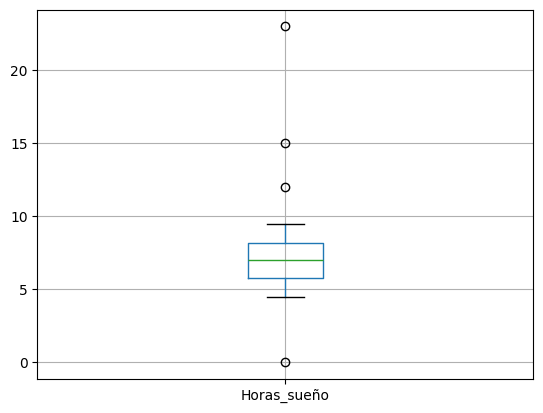

In [18]:
df1.boxplot('Horas_sueño')

In [19]:
df1.shape

(9698, 26)

In [20]:
outliers_ = outliers('Horas_sueño', df1)
df1 = df1.drop(outliers_.index)

* Se puede observar que se han removido 4 registros

In [21]:
df1.shape

(9694, 26)

### Eliminar columnas redundantes

In [22]:
import seaborn as sns
heatmap_df=df1.copy()
heatmap_df["Fumador"] = heatmap_df["Fumador"].cat.codes
heatmap_df["Alcohol"] = heatmap_df["Alcohol"].cat.codes
heatmap_df["Tiene_alergia"] = heatmap_df["Tiene_alergia"].cat.codes
heatmap_df["Nivel_Actividad"] = heatmap_df["Nivel_Actividad"].cat.codes
heatmap_df["Nivel_experiencia"] = heatmap_df["Nivel_experiencia"].cat.codes
numeric_df = heatmap_df.select_dtypes(include=['int64','float64','int8'])

sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f" )

<Axes: >

El análisis de correlación muestra que las variables Fumador y Alcohol presentan correlaciones altas con Cigarrillos_dia (0.87) y Alcohol_semana (0.85) respectivamente, lo que indica que contienen información duplicada. Asimismo, Peso y Altura presentan alta correlación con BMI (0.84 y -0.52), ya que el BMI se calcula a partir de estas variables. Por esta razón, se consideran variables redundantes y se eliminan para evitar multicolinealidad y mejorar el desempeño del modelo.

Las columnas redundantes deben ser eliminadas del modelo:
* Peso
* Altura
* Fumador
* Alcohol


In [23]:
remover = ['Peso', 'Altura', 'Fumador', 'Alcohol']
df1 = remove_cols(remover, df1)

In [24]:
df1.columns

Index(['Edad', 'Gnereo', 'BMI', 'Objetivo', 'Condicion_salud',
       'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida',
       'Horas_sueño', 'Entrenamiento_preferido', 'Cantidad_equipo',
       'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos',
       'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes',
       'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua', 'Plan_entrenamiento',
       'Plan_nutrición'],
      dtype='str')

### Análisis de Duplicados

No se encontraron registros duplicados

In [25]:
df1.duplicated().sum()

np.int64(0)

### Análisis variable de interés - Plan_entrenamiento



Se puede observar que existe un desbalanceo dentro de la categotia 'Alto' perteneciente a la variable de interés (Plan_entrenamiento), se debe aplicar SMOTE

In [26]:
df1['Plan_entrenamiento'].value_counts()

Plan_entrenamiento
Ninguno    3805
Medio      2944
Bajo       2289
Alto        656
Name: count, dtype: int64

### Análisis variable de interés - Plan_nutrición


Se puede observar que existe un desbalanceo dentro de la categotia 'Especializado' perteneciente a la variable de interés (Plan_nutrición), se debe aplicar SMOTE

In [27]:
df1['Plan_nutrición'].value_counts()

Plan_nutrición
Balanceado       4294
Sin plan         2522
Basico           2287
Especializado     591
Name: count, dtype: int64

# CONSTRUCCIÓN DEL PIPELINE - Regresión Logística para Plan_entrenamiento
---

Se desarrollarán 2 modelos de regresión logistica.

* El primer modelo se enfocará en estimar el Plan de entrenamiento.

* El segundo modelo se enfocará en estimar el Plan de nutrición.




A continuación se muestra la construcción del pipeline para la elaboración del modelomde regresión lineal para estimar el Plan de entrenamiento.

In [34]:
pipe.drop(outliers('Horas_sueño', pipe).index, inplace=True)

target = 'Plan_entrenamiento'
X = pipe.drop(columns=[target, 'Plan_nutrición'])
y = pipe[target]

le = LabelEncoder()
y_encoded = le.fit_transform(y) # Convertir la variable y en numeros

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

cols_to_drop = ['Peso','Altura','Fumador','Alcohol']

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors='ignore').copy()

dropper = FunctionTransformer(drop_columns)

def change_label(df):
    df_copy = df.copy()
    df_copy['Objetivo'] = df_copy['Objetivo'].replace('grasa', 'Perdida grasa')
    df_copy['Dieta_preferida'] = df_copy['Dieta_preferida'].replace('Animal', 'No-Vegetariano')
    return df_copy

changing_label = FunctionTransformer(change_label)


numeric_features = ['Edad','BMI', 'Horas_sueño', 'Cantidad_equipo', 'Tiempo_disponible', 'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
categoric_features = ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad','Nivel_experiencia','Dieta_preferida', 'Entrenamiento_preferido', 'Tiene_alergia','Problemas_digestivos']

numeric_transformer = StandardScaler()
categoric_transformer = OneHotEncoder(handle_unknown='ignore', drop='if_binary') #Ignora una categoria nueva, si variable tiene solo 2 categorias crea solo 1 col

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categoric_transformer, categoric_features)
    ]
)

pipeline_logit = ImbPipeline(
    steps=[
        ('drop_cols', dropper),
        ('change_label', changing_label),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), # SMOTE solo actúa sobre la variable objetivo "Plan_entrenamiento"
        ('modelo', LogisticRegression(max_iter=5000))
    ]
)

param_grid = [
    {
        'modelo__penalty': ['l2'],
        'modelo__solver':['newton-cg', 'lbfgs', 'saga'],
        'modelo__C': [0.1, 0.2, 0.5, 0.8, 1, 10, 50, 100, 1000]
    },
    {
        'modelo__penalty': ['l1'],
        'modelo__solver':['saga'], #Liblinear no sirve con multiclase
        'modelo__C':[0.1, 0.2, 0.5, 0.8, 1, 10, 50, 100, 1000]
    }
]

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

grid_rl = GridSearchCV(estimator=pipeline_logit, param_grid=param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)

grid_rl.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_rl.best_params_)
print("Mejor puntaje medio en CV (f1_macro):", grid_rl.best_score_)

resultados = pd.DataFrame(grid_rl.cv_results_)
cols = [
    'param_modelo__C',
    'param_modelo__penalty',
    'param_modelo__solver',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary = resultados[cols].sort_values(by='rank_test_score')
print("\nTop Resultados:")
print(summary.head())

best_model_entr_log = grid_rl.best_estimator_

y_pred_best = best_model_entr_log.predict(X_val)

report = classification_report(y_val, y_pred_best, target_names=le.classes_, output_dict=True)  # <- output_dict=True

precision_rl_plan_entrenamiento = report['weighted avg']['precision']
recall_rl_plan_entrenamiento  = report['weighted avg']['recall']
f1_rl_plan_entrenamiento  = report['weighted avg']['f1-score']

print(f"Precision: {precision_rl_plan_entrenamiento:.3f} | Recall: {recall_rl_plan_entrenamiento:.3f} | F1-score: {f1_rl_plan_entrenamiento:.3f}")

c:\Users\marce\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\marce\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Mejores hiperparámetros: {'modelo__C': 0.1, 'modelo__penalty': 'l1', 'modelo__solver': 'saga'}
Mejor puntaje medio en CV (f1_macro): 0.8844451404678416

Top Resultados:
    param_modelo__C param_modelo__penalty param_modelo__solver  \
27              0.1                    l1                 saga   
29              0.5                    l1                 saga   
16             10.0                    l2                lbfgs   
15             10.0                    l2            newton-cg   
17             10.0                    l2                 saga   

    mean_test_score  std_test_score  rank_test_score  
27         0.884445        0.014263                1  
29         0.884135        0.014267                2  
16         0.883336        0.014552                3  
15         0.883307        0.015249                4  
17         0.883307        0.015249                4  
Precision: 0.879 | Recall: 0.877 | F1-score: 0.877


Para el modelo de Regresión Logística, enfocado en estimar el Plan de entrenamiento, se realizó un proceso de selección de hiperparámetros utilizando validación cruzada con 10 folds, con el objetivo de encontrar la combinación que maximizara el desempeño del modelo según la métrica F1-score macro. Durante este proceso se evaluaron diferentes tipos de regularización (l1 y l2), distintos algoritmos de optimización (newton-cg, lbfgs y saga) y múltiples valores del parámetro de penalización C, el cual controla el grado de regularización aplicado al modelo y permite balancear el ajuste a los datos y la capacidad de generalización.

Como resultado, se encontró que los hiperparámetros que maximizan el desempeño del modelo son los siguientes:

* Regularización: l1
* Solver: saga
* Penalización (C): 0.1

El modelo obtuvo un F1-score promedio en validación cruzada de 0.884, lo que indica un buen desempeño en la clasificación del plan de entrenamiento. Al evaluar el modelo en el conjunto de validación, se obtuvo una precisión de 0.879, un recall de 0.877 y un F1-score de 0.877, lo que muestra un buen equilibrio entre la capacidad del modelo para identificar correctamente las clases y evitar errores de clasificación. Estos resultados sugieren que la regresión logística logra capturar relaciones relevantes entre las características del usuario, como el nivel de actividad, experiencia y objetivos físicos, y el tipo de plan de entrenamiento recomendado.

Mejor puntaje medio en CV (f1_macro): 0.8844451404678416

# CONSTRUCCIÓN DEL PIPELINE - Regresión Logística para Plan_nutrición
----

A continuación se muestra la construcción del pipeline para la elaboración del modelomde regresión lineal para estimar el Plan de nutrición.

In [35]:
pipe.drop(outliers('Horas_sueño', pipe).index, inplace=True)

target = 'Plan_nutrición'
X = pipe.drop(columns=[target, 'Plan_entrenamiento'])
y = pipe[target]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

cols_to_drop = ['Peso','Altura','Fumador','Alcohol']

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors='ignore').copy()

dropper = FunctionTransformer(drop_columns)

def change_label(df):
    df_copy = df.copy()
    df_copy['Objetivo'] = df_copy['Objetivo'].replace('grasa', 'Perdida grasa')
    df_copy['Dieta_preferida'] = df_copy['Dieta_preferida'].replace('Animal', 'No-Vegetariano')
    return df_copy

changing_label = FunctionTransformer(change_label)


numeric_features = ['Edad','BMI', 'Horas_sueño', 'Cantidad_equipo', 'Tiempo_disponible', 'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
categoric_features = ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad','Nivel_experiencia','Dieta_preferida', 'Entrenamiento_preferido', 'Tiene_alergia','Problemas_digestivos']

numeric_transformer = StandardScaler()
categoric_transformer = OneHotEncoder(handle_unknown='ignore', drop='if_binary')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categoric_transformer, categoric_features)
    ]
)

pipeline_logit = ImbPipeline(
    steps=[
        ('drop_cols', dropper),
        ('change_label', changing_label),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('modelo', LogisticRegression(max_iter=5000))
    ]
)

param_grid = [
    {
        'modelo__penalty': ['l2'],
        'modelo__solver':['newton-cg', 'lbfgs', 'saga'],
        'modelo__C': [0.1, 0.2, 0.5, 0.8, 1, 10, 50, 100, 1000]
    },
    {
        'modelo__penalty': ['l1'],
        'modelo__solver':['saga'],
        'modelo__C':[0.1, 0.2, 0.5, 0.8, 1, 10, 50, 100, 1000]
    }
]

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

grid_rl = GridSearchCV(estimator=pipeline_logit, param_grid=param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)

grid_rl.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_rl.best_params_)
print("Mejor puntaje medio en CV (f1_macro):", grid_rl.best_score_)

resultados = pd.DataFrame(grid_rl.cv_results_)
cols = [
    'param_modelo__C',
    'param_modelo__penalty',
    'param_modelo__solver',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary = resultados[cols].sort_values(by='rank_test_score')
print("\nTop Resultados:")
print(summary.head())

best_model_nutr_log = grid_rl.best_estimator_

y_pred_best = best_model_nutr_log.predict(X_val)

report = classification_report(y_val, y_pred_best, target_names=le.classes_, output_dict=True)  # <- output_dict=True

precision_rl_plan_nutricion = report['weighted avg']['precision']
recall_rl_plan_nutricion = report['weighted avg']['recall']
f1_rl_plan_nutricion = report['weighted avg']['f1-score']

print(f"Precision: {precision_rl_plan_nutricion:.3f} | Recall: {recall_rl_plan_nutricion:.3f} | F1-score: {f1_rl_plan_nutricion:.3f}")

c:\Users\marce\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\marce\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Mejores hiperparámetros: {'modelo__C': 0.5, 'modelo__penalty': 'l1', 'modelo__solver': 'saga'}
Mejor puntaje medio en CV (f1_macro): 0.7233112707259954

Top Resultados:
    param_modelo__C param_modelo__penalty param_modelo__solver  \
29              0.5                    l1                 saga   
26           1000.0                    l2                 saga   
34            100.0                    l1                 saga   
33             50.0                    l1                 saga   
35           1000.0                    l1                 saga   

    mean_test_score  std_test_score  rank_test_score  
29         0.723311        0.019983                1  
26         0.723225        0.019497                2  
34         0.723225        0.019497                2  
33         0.723225        0.019497                2  
35         0.723225        0.019497                2  
Precision: 0.797 | Recall: 0.758 | F1-score: 0.767


Para el modelo de **Regresión Logística**, enfocado en estimar el **Plan de nutrición**, se realizó un proceso de selección de hiperparámetros utilizando **validación cruzada con 10 folds**, con el fin de encontrar la combinación que maximizara el desempeño del modelo según la métrica **F1-score macro**. Durante este proceso se evaluaron distintos tipos de regularización (**l1 y l2**), diferentes algoritmos de optimización (**newton-cg, lbfgs y saga**) y varios valores del parámetro de penalización **C**, el cual controla el nivel de regularización aplicado al modelo.

Como resultado, se encontró que los hiperparámetros que maximizan el desempeño del modelo son los siguientes:

* **Regularización:** l1
* **Solver:** saga
* **Penalización (C):** 0.5

El modelo obtuvo un **F1-score promedio en validación cruzada de 0.723**, lo que indica un desempeño adecuado en la clasificación del plan de nutrición. Al evaluar el modelo en el conjunto de validación, se obtuvo una **precisión de 0.797**, un **recall de 0.758** y un **F1-score de 0.767**, lo que sugiere que el modelo logra capturar patrones relevantes en los datos, aunque la predicción del plan nutricional presenta una mayor dificultad en comparación con el plan de entrenamiento, posiblemente debido a una mayor variabilidad en los hábitos alimenticios de los usuarios.


# CONSTRUCCIÓN DEL PIPELINE - Árbol de Decisión para Plan_entrenamiento
---


In [37]:

from sklearn.ensemble import RandomForestClassifier
pipe.drop(outliers('Horas_sueño', pipe).index, inplace=True)

target = 'Plan_entrenamiento'
X = pipe.drop(columns=[target, 'Plan_nutrición'])
y = pipe[target]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

cols_to_drop = ['Peso','Altura','Fumador','Alcohol']

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors='ignore').copy()

dropper = FunctionTransformer(drop_columns)

def change_label(df):
    df_copy = df.copy()
    df_copy['Objetivo'] = df_copy['Objetivo'].replace('grasa', 'Perdida grasa')
    df_copy['Dieta_preferida'] = df_copy['Dieta_preferida'].replace('Animal', 'No-Vegetariano')
    return df_copy

changing_label = FunctionTransformer(change_label)


numeric_features = ['Edad','BMI', 'Horas_sueño', 'Cantidad_equipo', 'Tiempo_disponible', 'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
categoric_features = ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad','Nivel_experiencia','Dieta_preferida', 'Entrenamiento_preferido', 'Tiene_alergia','Problemas_digestivos']

numeric_transformer = StandardScaler()
categoric_transformer = OneHotEncoder(handle_unknown='ignore', drop='if_binary')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categoric_transformer, categoric_features)
    ]
)

pipeline_rf = ImbPipeline(
    steps=[
        ('drop_cols', dropper),
        ('change_label', changing_label),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('modelo', RandomForestClassifier(random_state=42))
    ]
)

param_grid = [
    {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__max_depth': [None, 10, 20, 30],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__min_samples_leaf': [1, 2, 4],
        'modelo__max_features': ['sqrt', 'log2']
    }
]

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

grid_rf = GridSearchCV(estimator=pipeline_rf, param_grid=param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)

grid_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print("Mejor puntaje medio en CV (f1_macro):", grid_rf.best_score_)

resultados = pd.DataFrame(grid_rf.cv_results_)
cols = [
    'param_modelo__n_estimators',
    'param_modelo__max_depth',
    'param_modelo__min_samples_split',
    'param_modelo__min_samples_leaf',
    'param_modelo__max_features',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary = resultados[cols].sort_values(by='rank_test_score')
print("\nTop Resultados:")
print(summary.head())

best_model_entr_rf = grid_rf.best_estimator_

y_pred_best = best_model_entr_rf.predict(X_val)

report = classification_report(y_val, y_pred_best, target_names=le.classes_, output_dict=True)  # <- output_dict=True

precision_rf_plan_entrenamiento = report['weighted avg']['precision']
recall_rf_plan_entrenamiento = report['weighted avg']['recall']
f1_rf_plan_entrenamiento = report['weighted avg']['f1-score']

print(f"Precision: {precision_rf_plan_entrenamiento:.3f} | Recall: {recall_rf_plan_entrenamiento:.3f} | F1-score: {f1_rf_plan_entrenamiento:.3f}")

Mejores hiperparámetros: {'modelo__max_depth': 20, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}
Mejor puntaje medio en CV (f1_macro): 0.9856087673412777

Top Resultados:
     param_modelo__n_estimators param_modelo__max_depth  \
112                         200                      20   
113                         300                      20   
2                           300                    None   
164                         300                      30   
111                         100                      20   

     param_modelo__min_samples_split  param_modelo__min_samples_leaf  \
112                                5                               1   
113                                5                               1   
2                                  2                               1   
164                                2                               1   
111                                5

El mejor modelo obtenido para la predicción del **Plan de nutrición** con  **Random Forest** fue con **200 árboles (n_estimators = 200)**, una profundidad máxima de **20 niveles (max_depth = 20)**, selección de variables en cada división utilizando la raíz cuadrada del número total de características (**max_features = 'sqrt'**), un mínimo de **5 muestras para dividir un nodo (min_samples_split = 5)** y al menos **1 muestra en cada hoja (min_samples_leaf = 1)**. Este modelo alcanzó un **F1-score de 0.986**, junto con valores de **precisión de 0.986** y **recall de 0.986**, lo que evidencia un desempeño sobresaliente y un balance muy alto entre la capacidad de clasificar correctamente los planes nutricionales y minimizar errores de predicción. Estos resultados indican que el modelo logra identificar patrones muy consistentes en los datos y generaliza adecuadamente para recomendar planes nutricionales acordes con el perfil del usuario.


# CONSTRUCCIÓN DEL PIPELINE - Árbol de Decisión para Plan_nutrición
---

In [36]:
pipe.drop(outliers('Horas_sueño', pipe).index, inplace=True)

target = 'Plan_nutrición'
X = pipe.drop(columns=[target, 'Plan_entrenamiento'])
y = pipe[target]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

cols_to_drop = ['Peso','Altura','Fumador','Alcohol']

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors='ignore').copy()

dropper = FunctionTransformer(drop_columns)

def change_label(df):
    df_copy = df.copy()
    df_copy['Objetivo'] = df_copy['Objetivo'].replace('grasa', 'Perdida grasa')
    df_copy['Dieta_preferida'] = df_copy['Dieta_preferida'].replace('Animal', 'No-Vegetariano')
    return df_copy

changing_label = FunctionTransformer(change_label)

numeric_features = ['Edad','BMI', 'Horas_sueño', 'Cantidad_equipo', 'Tiempo_disponible', 'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
categoric_features = ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad','Nivel_experiencia','Dieta_preferida', 'Entrenamiento_preferido', 'Tiene_alergia','Problemas_digestivos']

numeric_transformer = StandardScaler()
categoric_transformer = OneHotEncoder(handle_unknown='ignore', drop='if_binary')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categoric_transformer, categoric_features)
    ]
)

pipeline_rf_nut = ImbPipeline(
    steps=[
        ('drop_cols', dropper),
        ('change_label', changing_label),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('modelo', RandomForestClassifier(random_state=42))
    ]
)

param_grid = [
    {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__max_depth': [None, 10, 20, 30],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__min_samples_leaf': [1, 2, 4],
        'modelo__max_features': ['sqrt', 'log2']
    }
]

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

grid_rf_nut = GridSearchCV(estimator=pipeline_rf_nut, param_grid=param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)

grid_rf_nut.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_rf_nut.best_params_)
print("Mejor puntaje medio en CV (f1_macro):", grid_rf_nut.best_score_)

resultados = pd.DataFrame(grid_rf_nut.cv_results_)
cols = [
    'param_modelo__n_estimators',
    'param_modelo__max_depth',
    'param_modelo__min_samples_split',
    'param_modelo__min_samples_leaf',
    'param_modelo__max_features',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary = resultados[cols].sort_values(by='rank_test_score')
print("\nTop Resultados:")
print(summary.head())

best_model_nutr_rf = grid_rf_nut.best_estimator_

y_pred_best = best_model_nutr_rf.predict(X_val)

report = classification_report(y_val, y_pred_best, target_names=le.classes_, output_dict=True)

precision_rf_plan_nutricion = report['weighted avg']['precision']
recall_rf_plan_nutricion = report['weighted avg']['recall']
f1_rf_plan_nutricion = report['weighted avg']['f1-score']

print(f"Precision: {precision_rf_plan_nutricion:.3f} | Recall: {recall_rf_plan_nutricion:.3f} | F1-score: {f1_rf_plan_nutricion:.3f}")

Mejores hiperparámetros: {'modelo__max_depth': None, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}
Mejor puntaje medio en CV (f1_macro): 0.9661311551300018

Top Resultados:
     param_modelo__n_estimators param_modelo__max_depth  \
1                           200                    None   
163                         200                      30   
162                         100                      30   
0                           100                    None   
113                         300                      20   

     param_modelo__min_samples_split  param_modelo__min_samples_leaf  \
1                                  2                               1   
163                                2                               1   
162                                2                               1   
0                                  2                               1   
113                               

El mejor modelo obtenido para la predicción del Plan de entrenamiento con Random Forest,  fue el que tuvo los hiperparámetros de 200 árboles (n_estimators = 200), sin límite en la profundidad máxima del árbol (max_depth = None), considerando la raíz cuadrada del número de variables en cada división (max_features = 'sqrt'), y utilizando los valores mínimos por defecto para el número de muestras por nodo (min_samples_split = 2 y min_samples_leaf = 1). Este modelo obtuvo un F1-score de 0.977 en el conjunto de validación, junto con valores de precisión de 0.978 y recall de 0.977, lo que indica un excelente equilibrio entre la capacidad de identificar correctamente las clases y evitar errores de clasificación. Estos resultados sugieren que el modelo logra capturar de manera efectiva las relaciones entre las características del usuario y el plan recomendado, mostrando una alta capacidad de generalización sobre datos no vistos.

# Tabla Comparativa (recall, precisión y F1-score)

In [38]:
tabla_comparativa = pd.DataFrame([
    {
        'Modelo': 'Reg. Logistica Plan Entrenamiento',
        'precision': precision_rl_plan_entrenamiento,
        'recall': recall_rl_plan_entrenamiento,
        'F1-score': f1_rl_plan_entrenamiento
    },
    {
        'Modelo': 'Reg. Logistica Plan Nutricion',
        'precision': precision_rl_plan_nutricion,
        'recall': recall_rl_plan_nutricion,
        'F1-score': f1_rl_plan_nutricion
    },
    {
        'Modelo': 'Random Forest Plan Entrenamiento',
        'precision': precision_rf_plan_entrenamiento,
        'recall': recall_rf_plan_entrenamiento,
        'F1-score': f1_rf_plan_entrenamiento
    },
    {
        'Modelo': 'Random Forest Plan Nutricion',
        'precision': precision_rf_plan_nutricion,
        'recall': recall_rf_plan_nutricion,
        'F1-score': f1_rf_plan_nutricion
    }
])

tabla_comparativa

,Modelo,precision,recall,F1-score
0,Reg. Logistica Plan Entrenamiento,0.879270,0.877256,0.877487
1,Reg. Logistica Plan Nutricion,0.796613,0.757607,0.766849
2,Random Forest Plan Entrenamiento,0.985564,0.985560,0.985529
3,Random Forest Plan Nutricion,0.977638,0.977308,0.977267


# Variables más Relevantes en la Predicción (estimadores)

Función para obtener nombres de variables después del preprocesamiento

In [39]:
def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == 'remainder':
            continue

        if hasattr(transformer, 'get_feature_names_out'):
            try:
                names = transformer.get_feature_names_out(columns)
            except:
                names = transformer.get_feature_names_out()
            feature_names.extend(names)
        else:
            feature_names.extend(columns)

    return feature_names

Importancia de variables para Plan entrenamiento y nutrición con regresión logistica

In [42]:

# Obtener nombres de features transformadas
preprocessor_fitted = best_model_entr_log.named_steps['preprocessor']
feature_names = get_feature_names_from_preprocessor(preprocessor_fitted)

# Coeficientes del modelo
log_model = best_model_entr_log.named_steps['modelo']
coef_matrix = log_model.coef_

# Para multiclase: usar magnitud promedio absoluta de coeficientes
importance_logit = np.mean(np.abs(coef_matrix), axis=0)

# Crear tabla
importance_logit_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_logit
}).sort_values(by='Importance', ascending=False)

print("Top 15 variables más importantes - Regresión Logística - Plan_entrenamiento")
print(importance_logit_df.head(15))

Top 15 variables más importantes - Regresión Logística - Plan_entrenamiento
                              Feature  Importance
25               Nivel_Actividad_Alto   10.595834
28         Nivel_experiencia_Avanzado   10.528178
14         Objetivo_Ganancia muscular    5.402580
4                   Tiempo_disponible    2.202913
1                                 BMI    2.107337
30     Nivel_experiencia_Principiante    0.063051
11                    Gnereo_Femenino    0.060822
18               Condicion_salud_Asma    0.049542
16             Objetivo_Perdida grasa    0.048013
6                      Alcohol_semana    0.038752
21       Condicion_salud_Hipertension    0.037473
0                                Edad    0.037365
39  Entrenamiento_preferido_Funcional    0.037038
27           Nivel_Actividad_Moderado    0.022129
9                           Pasos_dia    0.021721


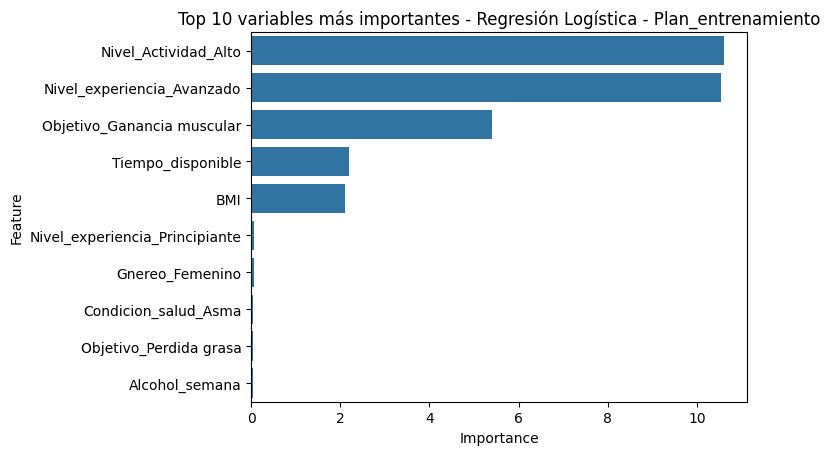

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=importance_logit_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 variables más importantes - Regresión Logística - Plan_entrenamiento')
plt.show()

In [45]:
preprocessor_fitted = best_model_nutr_log.named_steps['preprocessor']
feature_names = get_feature_names_from_preprocessor(preprocessor_fitted)

log_model = best_model_nutr_log.named_steps['modelo']
coef_matrix = log_model.coef_

importance_logit_nut = np.mean(np.abs(coef_matrix), axis=0)

importance_logit_nut_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_logit_nut
}).sort_values(by='Importance', ascending=False)

print("Top 15 variables más importantes - Regresión Logística - Plan_nutrición")
print(importance_logit_nut_df.head(15))

Top 15 variables más importantes - Regresión Logística - Plan_nutrición
                               Feature  Importance
15                    Objetivo_General    4.860776
17                Objetivo_Resistencia    4.735188
14          Objetivo_Ganancia muscular    4.435334
16              Objetivo_Perdida grasa    4.395515
1                                  BMI    1.806584
7                Score_micronutrientes    1.802075
6                       Alcohol_semana    1.582289
8                    Ingesta_proteinas    0.990122
18                Condicion_salud_Asma    0.194798
20  Condicion_salud_Enfermedad corazon    0.144646
24                Condicion_salud_PCOS    0.133600
13                         Gnereo_Otro    0.120912
36      Entrenamiento_preferido_Cardio    0.091265
32        Dieta_preferida_Pescetariano    0.090075
27            Nivel_Actividad_Moderado    0.086891


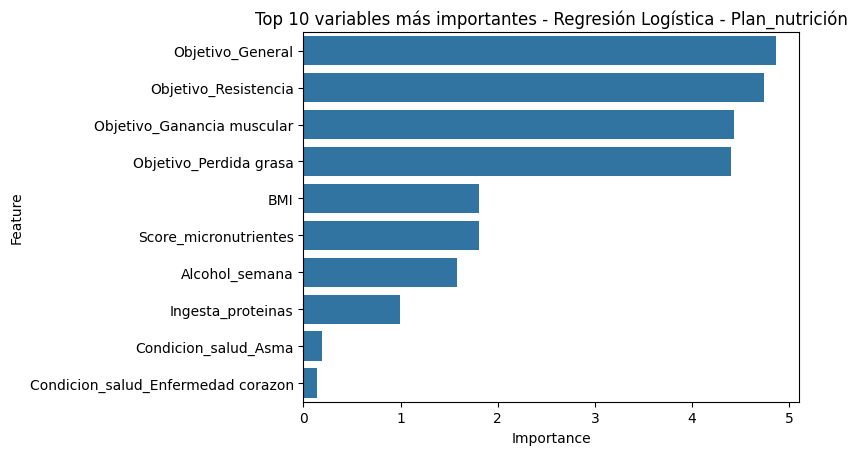

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=importance_logit_nut_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 variables más importantes - Regresión Logística - Plan_nutrición')
plt.show()

Importancia de variables para plan nutrición y entrenamiento para arboles de decisión

In [47]:
preprocessor_fitted = best_model_entr_rf.named_steps['preprocessor']
feature_names = get_feature_names_from_preprocessor(preprocessor_fitted)

rf_model = best_model_entr_rf.named_steps['modelo']
importance_rf = rf_model.feature_importances_

importance_rf_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_rf
}).sort_values(by='Importance', ascending=False)

print("Top 15 variables más importantes - Random Forest - Plan_entrenamiento")
print(importance_rf_df.head(15))

Top 15 variables más importantes - Random Forest - Plan_entrenamiento
                           Feature  Importance
28      Nivel_experiencia_Avanzado    0.144115
25            Nivel_Actividad_Alto    0.142176
4                Tiempo_disponible    0.110610
1                              BMI    0.106963
14      Objetivo_Ganancia muscular    0.068445
27        Nivel_Actividad_Moderado    0.053773
26            Nivel_Actividad_Bajo    0.050763
29    Nivel_experiencia_Intermedio    0.046256
30  Nivel_experiencia_Principiante    0.043033
10                    Ingesta_agua    0.015935
9                        Pasos_dia    0.015839
8                Ingesta_proteinas    0.015432
16          Objetivo_Perdida grasa    0.014877
15                Objetivo_General    0.014842
7            Score_micronutrientes    0.014825


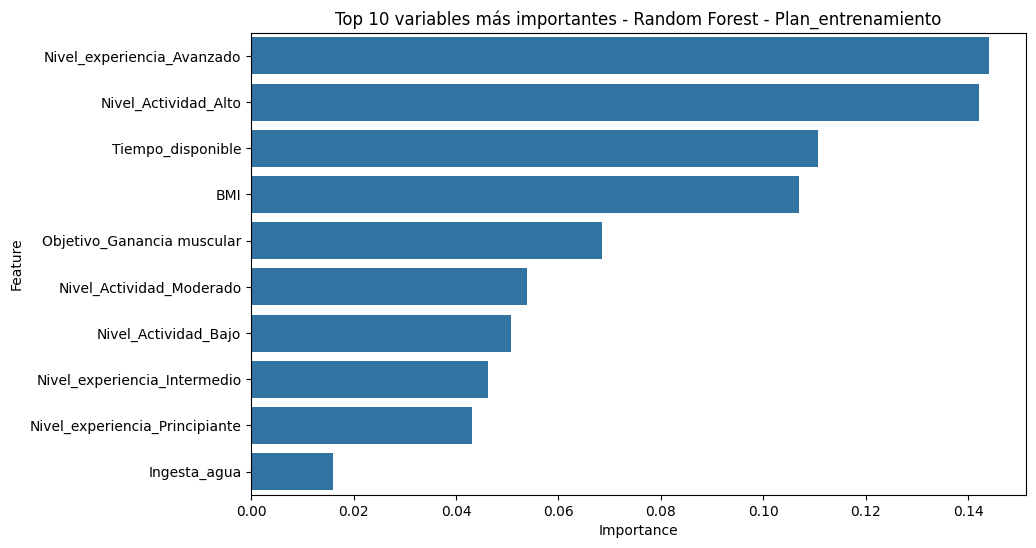

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=importance_rf_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 variables más importantes - Random Forest - Plan_entrenamiento')
plt.show()

In [49]:
preprocessor_fitted = best_model_nutr_rf.named_steps['preprocessor']
feature_names = get_feature_names_from_preprocessor(preprocessor_fitted)

rf_model = best_model_nutr_rf.named_steps['modelo']
importance_rf_nut = rf_model.feature_importances_

importance_rf_nut_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_rf_nut
}).sort_values(by='Importance', ascending=False)

print("Top 15 variables más importantes - Random Forest - Plan_nutrición")
print(importance_rf_nut_df.head(15))

Top 15 variables más importantes - Random Forest - Plan_nutrición
                       Feature  Importance
1                          BMI    0.132239
7        Score_micronutrientes    0.124513
6               Alcohol_semana    0.118876
15            Objetivo_General    0.083440
8            Ingesta_proteinas    0.080402
17        Objetivo_Resistencia    0.077756
14  Objetivo_Ganancia muscular    0.071492
16      Objetivo_Perdida grasa    0.065771
9                    Pasos_dia    0.019309
10                Ingesta_agua    0.018366
0                         Edad    0.017842
4            Tiempo_disponible    0.017588
2                  Horas_sueño    0.016926
3              Cantidad_equipo    0.013692
23     Condicion_salud_Ninguno    0.007663


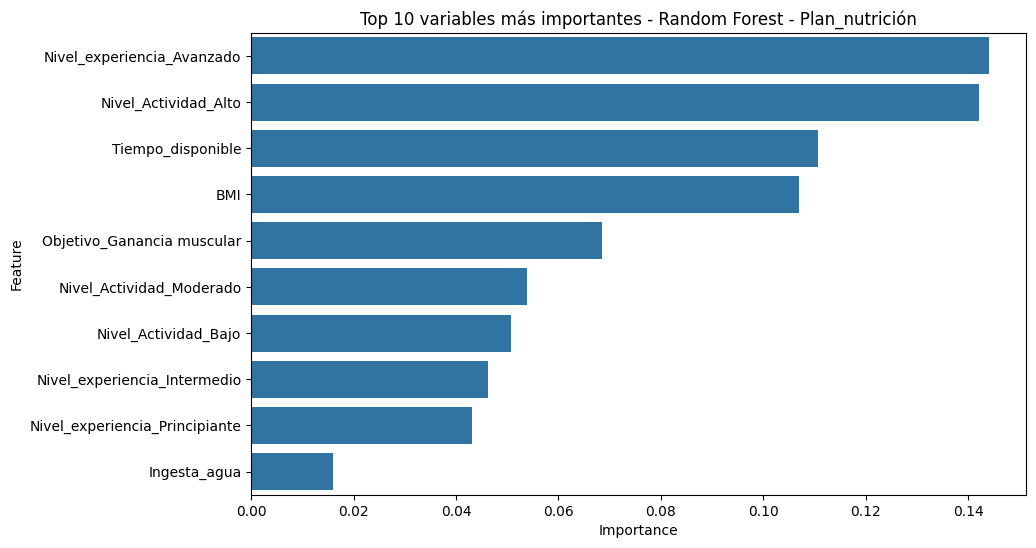

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=importance_rf_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 variables más importantes - Random Forest - Plan_nutrición')
plt.show()

El análisis de importancia de variables se hizo con regresión logística y árboles de decisión (Random Forest), para ver qué factores del perfil del usuario influyen más en la recomendación de planes de entranamiento y nutricion. En la regresión logística la relevancia se midió por la magnitud de los coeficientes que muestran la influencia lineal de cada característica sobre la probabilidad de pertenecer a una clase. En el modelo de árboles la importancia se calculó con la reducción promedio de impureza que genra cada variable en los arboles del modelo, lo que permite capturar relaciones no lineales e interacciones entre variables

Los resultados muestran que variables como Nivel_Actividad, Nivel_experiencia Tiempo_disponible, BMI, Objetivo tienen gran peso en la predicción del plan de entrenamiento. Esto es lógico porque el estado físico actual y las metas personales determinan la rutina recomendada. En nutrición, las variables más influyentes fueron Objetivo, Score_micronutrientes, Ingesta_proteinas , BMI y algunos indicadores de habitos de consumo que presentan alta relevancia, lo que evidencia que tanto la alimentación como la condición corporal impactan en la recomendación nutricional aunque en algunos casos se mezclan con otras variables menos claras.

Al comparar ambos enfoques se observa que coinciden en destacar variables similares lo que confirma que esas características contienen información clave para la decisión. Sin embargo, el modelo de árboles distribuye la importancia entre más variables gracias a que puede capturar relaciones no lineales y combinaciones entre características, mientras que la regresión logística concentra la relevancia de las variables en aquellas tienen relación más lineal con la variable objetivo. Esta comparación permite comprender cómo distintos métodos resaltan diferentes aspectos del perfil del usuario y contribuye a una mejor interpretación de los factores que influyen en la recomendación de planes personalizados.

# BONO: Modelo Multi-etiqueta

In [54]:
pipe.drop(outliers('Horas_sueño', pipe).index, inplace=True)

# El target ahora contiene ambas columnas
targets = ['Plan_entrenamiento', 'Plan_nutrición']
X = pipe.drop(columns=targets)
y = pipe[targets]

le_ent = LabelEncoder()
le_nut = LabelEncoder()

y_encoded = pd.DataFrame({
    'Plan_entrenamiento': le_ent.fit_transform(y['Plan_entrenamiento']),
    'Plan_nutrición':     le_nut.fit_transform(y['Plan_nutrición'])
})

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

cols_to_drop = ['Peso','Altura','Fumador','Alcohol']

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors='ignore').copy()

dropper = FunctionTransformer(drop_columns)

def change_label(df):
    df_copy = df.copy()
    df_copy['Objetivo'] = df_copy['Objetivo'].replace('grasa', 'Perdida grasa')
    df_copy['Dieta_preferida'] = df_copy['Dieta_preferida'].replace('Animal', 'No-Vegetariano')
    return df_copy

changing_label = FunctionTransformer(change_label)

numeric_features = ['Edad','BMI', 'Horas_sueño', 'Cantidad_equipo', 'Tiempo_disponible', 'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
categoric_features = ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad','Nivel_experiencia','Dieta_preferida', 'Entrenamiento_preferido', 'Tiene_alergia','Problemas_digestivos']

numeric_transformer = StandardScaler()
categoric_transformer = OneHotEncoder(handle_unknown='ignore', drop='if_binary')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categoric_transformer, categoric_features)
    ]
)

from sklearn.multioutput import MultiOutputClassifier

base_pipeline = ImbPipeline(
    steps=[
        ('drop_cols', dropper),
        ('change_label', changing_label),
        ('preprocessor', preprocessor),
        ('modelo', MultiOutputClassifier(
            LogisticRegression(max_iter=5000, class_weight='balanced')
        ))
    ]
)

param_grid = [
    {
        'modelo__estimator__penalty': ['l2'],
        'modelo__estimator__solver': ['newton-cg', 'lbfgs', 'saga'],
        'modelo__estimator__C': [0.1, 0.5, 1, 10, 100]
    },
    {
        'modelo__estimator__penalty': ['l1'],
        'modelo__estimator__solver': ['saga'],
        'modelo__estimator__C': [0.1, 0.5, 1, 10, 100]
    }
]

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

grid_multi = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring='f1_macro',
    n_jobs=-1
)

grid_multi.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_multi.best_params_)
print("Mejor puntaje medio en CV (f1_macro):", grid_multi.best_score_)

best_model = grid_multi.best_estimator_
y_pred = best_model.predict(X_val)

resultados_multi = {}

for i, (target_name, le) in enumerate([
    ('Plan_entrenamiento', le_ent),
    ('Plan_nutrición', le_nut)
]):

    report = classification_report(
        y_val.iloc[:, i],
        y_pred[:, i],
        target_names=le.classes_,
        output_dict=True
    )

    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']

    resultados_multi[target_name] = {
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    print(f"\nReporte - {target_name}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

c:\Users\marce\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(
c:\Users\marce\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\marce\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

Mejores hiperparámetros: {'modelo__estimator__C': 0.1, 'modelo__estimator__penalty': 'l2', 'modelo__estimator__solver': 'newton-cg'}
Mejor puntaje medio en CV (f1_macro): nan

Reporte - Plan_entrenamiento
Precision: 0.875
Recall: 0.868
F1-score: 0.869

Reporte - Plan_nutrición
Precision: 0.791
Recall: 0.744
F1-score: 0.754


In [55]:
#Tabla comparativa para el modelo multioutput
tabla_multi = pd.DataFrame([
    {
        "Modelo": "Multioutput Logistic",
        "Target": "Plan_entrenamiento",
        "Precision": resultados_multi["Plan_entrenamiento"]["precision"],
        "Recall": resultados_multi["Plan_entrenamiento"]["recall"],
        "F1-score": resultados_multi["Plan_entrenamiento"]["f1"]
    },
    {
        "Modelo": "Multioutput Logistic",
        "Target": "Plan_nutrición",
        "Precision": resultados_multi["Plan_nutrición"]["precision"],
        "Recall": resultados_multi["Plan_nutrición"]["recall"],
        "F1-score": resultados_multi["Plan_nutrición"]["f1"]
    }
])

tabla_multi

,Modelo,Target,Precision,Recall,F1-score
0,Multioutput Logistic,Plan_entrenamiento,0.875021,0.867973,0.869081
1,Multioutput Logistic,Plan_nutrición,0.790829,0.744198,0.754348


El modelo multietiqueta basado en regresión logística mostró un buen desempeño al predecir simultáneamente el plan de entrenamiento y el plan de nutrición. Para **Plan_entrenamiento**, se obtuvo un F1-score de **0.869**, lo que indica que el modelo logra identificar adecuadamente las características del usuario relacionadas con su nivel de actividad, experiencia y objetivos físicos. En el caso de **Plan_nutrición**, el F1-score fue de **0.754**, mostrando un desempeño ligeramente menor, posiblemente debido a una mayor variabilidad en los hábitos alimenticios y factores nutricionales de los usuarios. En general, los resultados sugieren que el enfoque multietiqueta permite obtener predicciones consistentes para ambos objetivos utilizando un único pipeline, facilitando la implementación del modelo en una plataforma como SmartAlpes para generar recomendaciones personalizadas de manera eficiente.


## Generación de predicciones al mejor modelo

In [57]:
# Mejor modelo para Plan_entrenamiento
if f1_rf_plan_entrenamiento > f1_rl_plan_entrenamiento:
    best_model_entrenamiento = best_model_entr_rf
else:
    best_model_entrenamiento = best_model_entr_log


# Mejor modelo para Plan_nutrición
if f1_rf_plan_nutricion > f1_rl_plan_nutricion:
    best_model_nutricion = best_model_nutr_rf
else:
    best_model_nutricion = best_model_nutr_log

In [59]:
pred_entrenamiento = best_model_entrenamiento.predict(df_test)

pred_nutricion = best_model_nutricion.predict(df_test)

# convertir a etiquetas originales
pred_entrenamiento = le_ent.inverse_transform(pred_entrenamiento)
pred_nutricion = le_nut.inverse_transform(pred_nutricion)


# agregar columnas al dataset original
df_test["Plan_entrenamiento"] = pred_entrenamiento

df_test["Plan_nutrición"] = pred_nutricion


# exportar csv final
df_test.to_csv(
    "./Datos_test_Lab3_predicciones.csv",
    sep=";",
    index=False,
    encoding="latin-1"
)

# Análisis de Resultados

* **¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?**

El análisis de importancia de variables hecho con regresión logística y Random Forest muestra que las características más influyentes en la recomendación del plan de entrenamiento están ligadas sobre todo al nivel de condición física y al objetivo del usuario. Variables como Nivel_Actividad, Nivel_experiencia, Tiempo_disponible, BMI y Objetivo aparecen con alta relevancia en ambos modelos, lo que sugiere que la rutina depende del estado físico actual, la experiencia previa y el tiempo que puede dedicar al entrenamiento.

De forma parecida, en el plan nutricional destacan Objetivo, Score_micronutrientes, Ingesta_proteinas, BMI y algunos hábitos de consumo, indicando que las recomendaciones alimenticias dependen en gran medida de las metas físicas y de los patrones de alimentación del usuario.

Estos resultados son coherentes con el dominio del problema ya que tanto el entrenamiento como la nutrición deben adaptarse al estilo de vida y a las necesidades fisiológicas del cliente. En conclusión los dos modelos coinciden en resaltar variables similares aunque el Random Forest tiende a repartir la importancia entre más factores mientras la regresión logística concentra la relevancia en relaciones más lineales.

* **¿Existen variables que podrían ser redundantes o poco informativas?**

Sí, durante el análisis exploratorio identificamos algunas variables redundantes que aportaban información duplicada. En particular, Peso y Altura estaban muy correlacionadas con la variable BMI, esto dado que el índice de masa corporal se calcula usando estas dos variables. Asimismo, las variables Fumador y Alcohol presentan alta correlación con Cigarrillos_dia y Alcohol_semana, respectivamente, lo que nos hace creer que contienen información similar sobre los hábitos del usuario. De acuerdo con lo visto en clase sobre multicolinealidad, mantener variables altamente correlacionadas puede generar inestabilidad en los modelos lineales y aumentar la complejidad sin mejorar la capacidad predictiva. Por esta razón, se eliminaron estas variables para reducir la dimensionalidad y mejorar la capacidad de generalización del modelo.

* **¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?**

Los resultados que obtuvimos muestran que los modelos logran reproducir adecuadamente las recomendaciones presentes en el dataset. Más especificamente, los modelos de regresión logística y Random Forest obtuvieron valores altos de F1-score, lo que nos indica que tienen un buen balance entre precisión y recall. Para el plan de entrenamiento se obtuvo un F1-score cercano a 0.87–0.88, lo que significa que el modelo logra identificar correctamente la mayoría de las clases sin generar un número elevado de errores. En el caso del plan nutricional, el F1-score fue ligeramente menor (alrededor de 0.72–0.75), lo que sugiere que esta predicción puede ser más compleja debido a una mayor variabilidad en los hábitos alimenticios de los usuarios. En general, los resultados indican que el modelo logra capturar patrones relevantes del dataset y generalizar adecuadamente a nuevos datos, lo cual coincide con el objetivo del problema planteado.

* **A partir de alguno de los modelos creados con árboles de decisión, describa en términos de reglas, las características que cumplen las variables involucradas en la recomendación que se da. Incluya además, la utilidad y la limitación que tienen este estilo de reglas en modelos de árboles de decisión principalmente en el proceso de explicabilidad del modelo.**

In [56]:
# Ver las reglas de un arbol específico dentro del Random Forest para Plan_entrenamiento
from sklearn.tree import export_text

rf_model = best_model_entr_rf.named_steps["modelo"]

# tomar un árbol del bosque
tree = rf_model.estimators_[0]

# obtener nombres de variables transformadas
feature_names = get_feature_names_from_preprocessor(
    best_model.named_steps["preprocessor"]
)

rules = export_text(tree, feature_names=list(feature_names))

print(rules[:2000])

|--- Nivel_Actividad_Bajo <= 1.00
|   |--- Gnereo_Masculino <= 1.00
|   |   |--- Nivel_experiencia_Intermedio <= 0.99
|   |   |   |--- Nivel_experiencia_Avanzado <= 0.00
|   |   |   |   |--- Objetivo_Ganancia muscular <= 0.22
|   |   |   |   |   |--- Nivel_Actividad_Alto <= 0.09
|   |   |   |   |   |   |--- Nivel_experiencia_Intermedio <= 0.01
|   |   |   |   |   |   |   |--- BMI <= 0.23
|   |   |   |   |   |   |   |   |--- class: 3.0
|   |   |   |   |   |   |   |--- BMI >  0.23
|   |   |   |   |   |   |   |   |--- Alcohol_semana <= 1.97
|   |   |   |   |   |   |   |   |   |--- Condicion_salud_Ninguno <= 0.04
|   |   |   |   |   |   |   |   |   |   |--- Tiempo_disponible <= 0.23
|   |   |   |   |   |   |   |   |   |   |   |--- class: 3.0
|   |   |   |   |   |   |   |   |   |   |--- Tiempo_disponible >  0.23
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- Condicion_salud_Ninguno >  0.04
|   |   |   |   |   |   |   |   |   |   |--- Pas

A partir del modelo basado en árboles (Random Forest), es posible interpretar la recomendación del plan como un conjunto de reglas que relacionan las características del usuario con el tipo de plan sugerido. En las reglas extraídas del árbol se observa que variables como Nivel_Actividad, Nivel_experiencia, Objetivo, BMI y Tiempo_disponible aparecen en los nodos superiores, lo que indica que son factores clave en la decisión del modelo. Por ejemplo, el árbol primero divide a los usuarios según su nivel de actividad física y experiencia, lo que sugiere que el estado físico actual influye en la intensidad del plan recomendado. Luego, variables como el Objetivo del usuario y el BMI permiten mejorar la recomendación, dado que diferencia entre usuarios que buscan pérdida de grasa, mantenimiento o ganancia muscular. Además, variables que tienen que ver con hábitos de vida como Pasos_dia, Alcohol_semana e Ingesta_agua aparecen en niveles más profundos del árbol, lo que indica que el modelo utiliza información adicional del estilo de vida para ajustar la recomendación final. La utilidad de este tipo de reglas radica en su alta interpretabilidad, ya que permiten comprender mejor cómo diferentes características del usuario influyen en la decisión del modelo, lo que ayuda a entender de manera clara por qué el modelo toma cada decisión.. Sin embargo, una limitación es que los árboles pueden generar reglas complejas y sensibles a los datos de entrenamiento, lo que puede producir modelos con alta varianza o reglas que no generalicen bien a nuevos datos, tal como se discute en el curso al analizar el trade-off entre sesgo y varianza en modelos de aprendizaje supervisado.

* **¿Cómo podría integrarse este tipo de modelo en una plataforma digital de fitness o bienestar?**

Este modelo podría integrarse en una plataforma digital como un sistema de recomendación automatizado que sugiera planes personalizados de entrenamiento y nutrición a partir de la información del usuario. Por ejemplo, cuando una persona se registra en la aplicación, podría ingresar datos como su edad, nivel de actividad, experiencia, objetivo físico, hábitos alimenticios y disponibilidad de tiempo. El modelo procesaría esta información y generaría recomendaciones adaptadas a su perfil en tiempo real, ayudando a ofrecer un servicio más personalizado y consistente. Además, la plataforma podría actualizar las recomendaciones a medida que el usuario cambie sus hábitos o avance en su progreso, mejorando la experiencia del usuario y facilitando la toma de decisiones basada en datos.

* **¿Qué limitaciones tendría utilizar un sistema automático para recomendar planes de entrenamiento?**

Una limitación importante de un sistema automático es que no puede capturar completamente todos los factores individuales que influyen en el bienestar de una persona, como lesiones previas, condiciones médicas específicas o preferencias personales que no estén registradas en los datos. Además, el modelo depende de la calidad de la información disponible, por lo que si los datos son incompletos o no representan adecuadamente a todos los tipos de usuarios, las recomendaciones podrían no ser las más adecuadas. También existe el riesgo de que el modelo simplifique demasiado el proceso de recomendación, ya que no reemplaza completamente el criterio de un profesional, sino que debe utilizarse como una herramienta de apoyo para mejorar la toma de decisiones.

* **¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?**

El sesgo puede aparecer si el dataset no representa adecuadamente a todos los tipos de usuarios, por ejemplo si hay mayor cantidad de personas con ciertos niveles de actividad física, edades o estilos de vida específicos. También puede existir sesgo en la forma en que se asignaron originalmente los planes, ya que las recomendaciones hechas por entrenadores pueden depender de criterios subjetivos o de su experiencia personal. Además, el desbalance en algunas categorías puede hacer que el modelo aprenda mejor ciertos patrones y tenga menor precisión en grupos menos representados. Esto puede afectar la equidad del sistema, ya que el modelo podría funcionar mejor para algunos perfiles de usuario que para otros, lo que resalta la importancia de revisar la calidad de los datos y evaluar continuamente el desempeño del modelo.

## Uso IA Generativa

**Declaración del uso**

Durante el desarrollo de este laboratorio se utilizó la herramienta ChatGPT (OpenAI) como apoyo en el proceso de aprendizaje. La IA generativa se empleó principalmente para:

Aclarar conceptos teóricos vistos en el curso, como SMOTE, regresión logística multiclase, Random Forest, importancia de variables y sesgo-varianza.
Entender el funcionamiento de partes específicas del código, especialmente en la construcción de pipelines, transformaciones de variables y evaluación de modelos.
Resolver dudas sobre errores comunes de implementación en Python y scikit-learn.
Mejorar la redacción de los textos del análisis de resultados, buscando mayor claridad, coherencia y precisión técnica.
Verificar la correcta interpretación de los resultados obtenidos en las gráficas de importancia de variables y métricas de desempeño.

La herramienta fue utilizada como apoyo conceptual y de revisión, pero las decisiones finales sobre el modelo, selección de variables, interpretación de resultados y estructura del laboratorio fueron tomadas por el estudiante.

**Prompts utilizados (resumen)**

Algunos ejemplos de prompts utilizados durante el proceso incluyen:

"Explícame cómo funciona SMOTE y cuándo se debe usar"
"¿Cuál es la diferencia entre entropy y gini en árboles de decisión?"
"Ayúdame a interpretar la importancia de variables en Random Forest"
"¿Por qué liblinear no funciona bien con multiclase?"
"Explícame qué hace este código en el pipeline"
"Ayúdame a mejorar la redacción de esta interpretación de resultados de los modelos"
"Cómo seleccionar el mejor modelo usando F1-score"

Los prompts se enfocaron en mejorar la comprensión de conceptos del curso y en asegurar la correcta implementación del pipeline de Machine Learning.

**Análisis crítico del resultado**

La IA generativa fue útil para aclarar conceptos complejos como el funcionamiento de SMOTE y la interpretación de la importancia de variables en modelos de árboles y regresión logística. También ayudó a identificar errores comunes en el uso de GridSearchCV, el manejo de variables categóricas y la correcta estructura de los pipelines, lo cual permitió mejorar la calidad del modelo final.

Sin embargo, algunas respuestas iniciales requerían verificación con el material del curso, especialmente en la interpretación de reglas del árbol de decisión, ya que no todas las reglas pueden afirmarse directamente sin revisar la estructura específica del modelo entrenado.

Los conceptos vistos en clase, como multicolinealidad, generalización, interpretabilidad de modelos,validación cruzada, o SMOTE permitieron evaluar críticamente las sugerencias generadas y asegurar que el desarrollo del laboratorio estuviera alineado con los objetivos del curso.

**Aportes propios del estudiante**

El estudiante realizó la limpieza de datos, análisis exploratorio, selección de variables redundantes y construcción de los pipelines de Machine Learning utilizando regresión logística, Random Forest y un modelo multietiqueta. También se tomaron decisiones propias sobre el uso de SMOTE para manejar el desbalance de clases y la selección del mejor modelo con base en la métrica F1-score.

Asimismo, el estudiante interpretó las gráficas de importancia de variables y relacionó los resultados con el contexto del problema de recomendación de planes de entrenamiento y nutrición. La IA generativa se utilizó principalmente para mejorar la claridad en la explicación escrita y asegurar coherencia en la interpretación de los resultados, pero el análisis conceptual y las decisiones técnicas fueron realizadas por el estudiante.

El proceso permitió reforzar la comprensión de cómo construir pipelines completos de Machine Learning, cómo evaluar modelos de clasificación multiclase y cómo interpretar la importancia de variables para explicar el comportamiento de los modelos.